## Week 3 :- Univariate and Bivariate

3.1 Number of flights per month

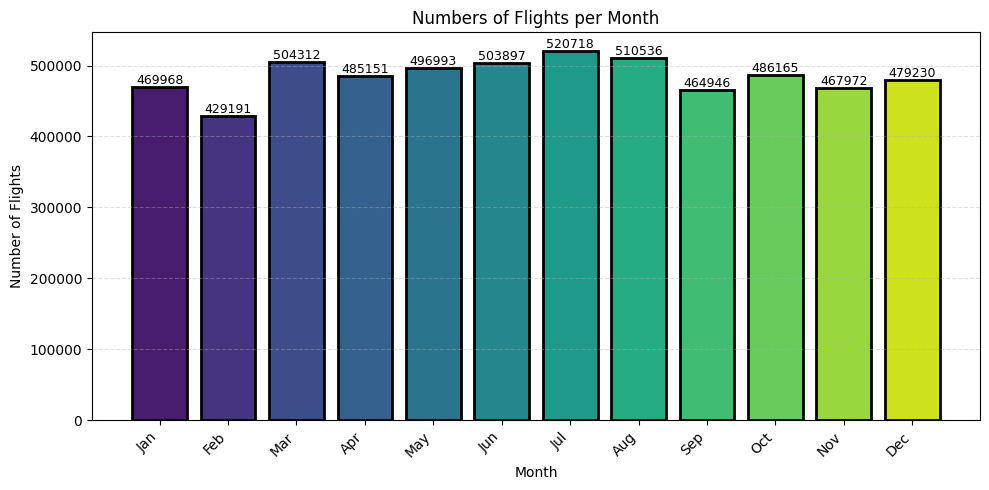

In [39]:
plt.figure(figsize=(10, 5))
current_month_counts = df['MONTH'].value_counts()
month_counts = current_month_counts.reindex(range(1, 13), fill_value=0).sort_index()

color = sns.color_palette("viridis", len(month_counts))
plt.bar(month_counts.index, month_counts.values, color=color, edgecolor='black', linewidth=2)

plt.title('Numbers of Flights per Month')
plt.xlabel('Month')
plt.ylabel('Number of Flights')

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.xticks(month_counts.index, month_names, rotation=45, ha='right') 
plt.grid(axis='y', linestyle='--', alpha=0.4)
for i, value in enumerate(month_counts.values):
    plt.text(month_counts.index[i], value + 200, str(value), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


3.2 Number of flights per day in a week

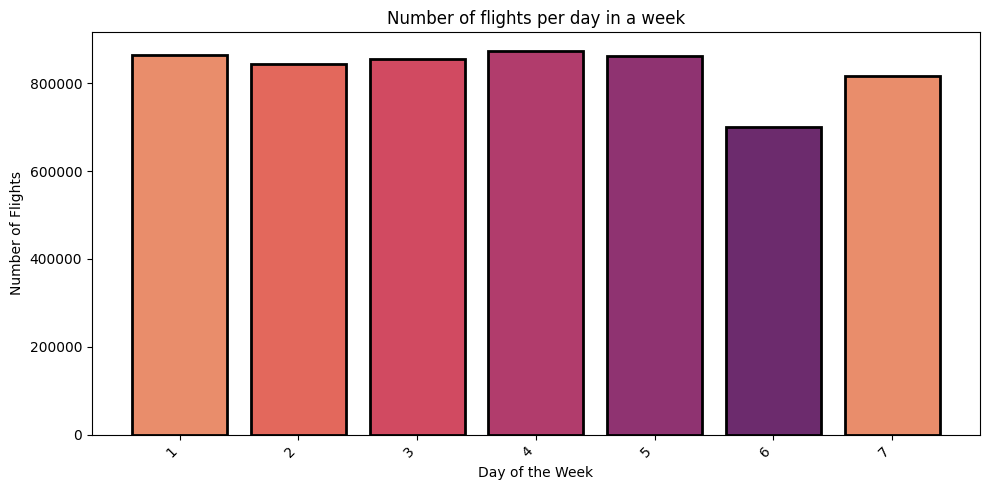

In [40]:
plt.figure(figsize=(10, 5))

week_counts = df['DAY_OF_WEEK'].value_counts().sort_index()

color = sns.color_palette("flare")

plt.bar(week_counts.index, week_counts.values, color=color, edgecolor='black', linewidth=2)
plt.title('Number of flights per day in a week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Flights')

plt.xticks(week_counts.index, rotation=45, ha='right')

plt.tight_layout()
plt.show()
     

3.3 Number of flights per airline

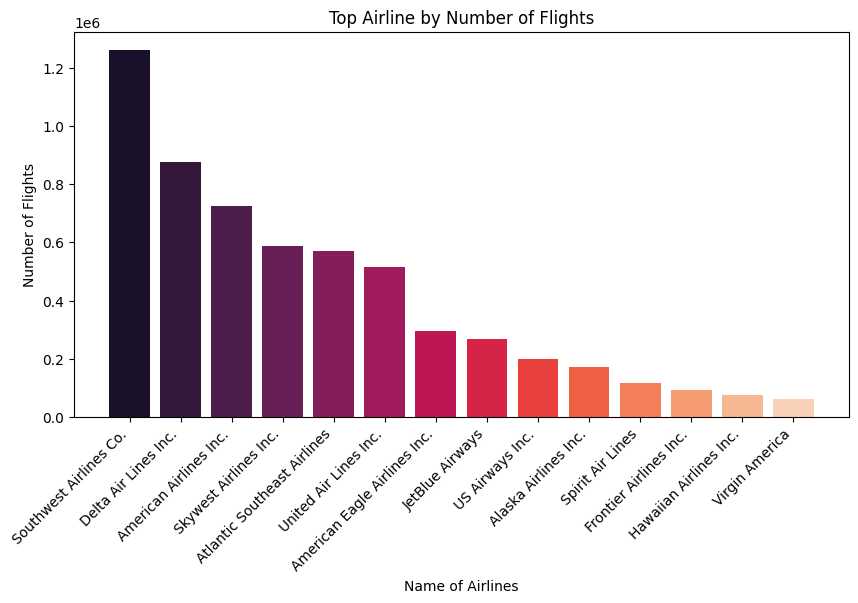

In [41]:
plt.figure(figsize=(10, 5))
airline_counts = df['AIRLINE_NAME'].value_counts().sort_values(ascending=False)
color = sns.color_palette("rocket", len(airline_counts))

plt.bar(airline_counts.index, airline_counts.values, color=color)
plt.title('Top Airline by Number of Flights')
plt.xlabel('Name of Airlines')
plt.ylabel('Number of Flights')
plt.xticks(rotation=45, ha='right')
plt.show()

3.4 Weekend Vs Weekdays flights

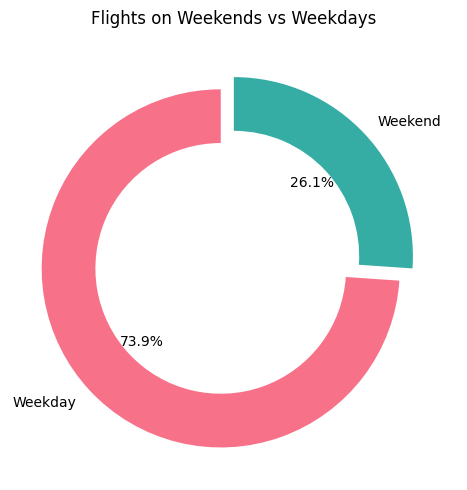

In [42]:
plt.figure(figsize=(8, 5))
weekend_counts = df['IS_WEEKEND'].value_counts()

color = sns.color_palette("husl", len(weekend_counts))
descriptive_labels = ['Weekday' if label == False else 'Weekend' for label in weekend_counts.index]

plt.pie(
    weekend_counts.values,
    labels=descriptive_labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=color,
    wedgeprops={'width': 0.3,'linewidth': 2},
    explode=(0.1, 0)
)
plt.title('Flights on Weekends vs Weekdays')
plt.tight_layout()
plt.show()
     

3.5 Flights By Arrival & Departure Hour

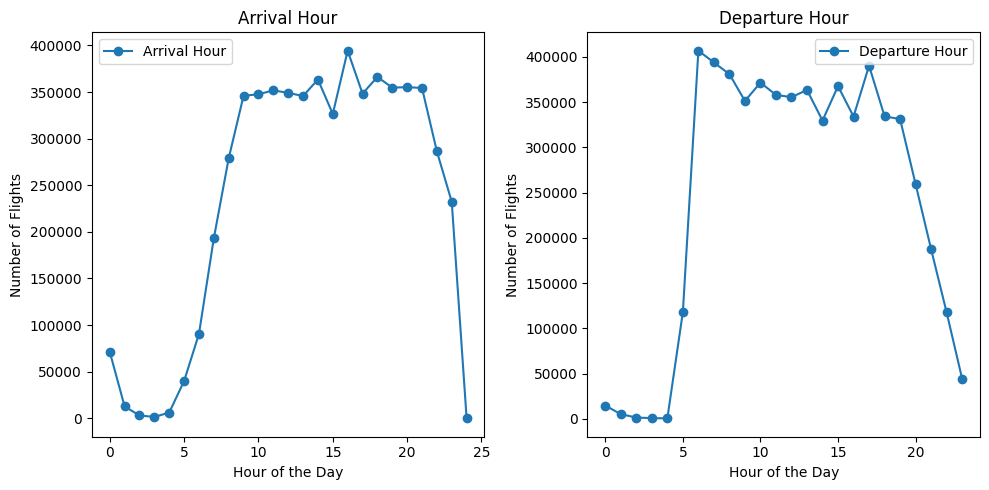

In [43]:
plt.figure(figsize=(10, 5))

arrival_hour_counts = df['ARRIVAL_HOUR'].value_counts().sort_index()
departure_hour_counts = df['DEPARTURE_HOUR'].value_counts().sort_index()

# Flights by Arrival Hour
plt.subplot(1, 2, 1)
plt.plot(arrival_hour_counts.index, arrival_hour_counts.values, label='Arrival Hour', marker='o')
plt.title('Arrival Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Flights')
plt.legend()

# Flights by Departure Hour
plt.subplot(1, 2, 2)
plt.plot(departure_hour_counts.index, departure_hour_counts.values, label='Departure Hour', marker='o')
plt.title('Departure Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Flights')
plt.legend()

plt.tight_layout()
plt.show()

3.6 Top 15 most visited cities

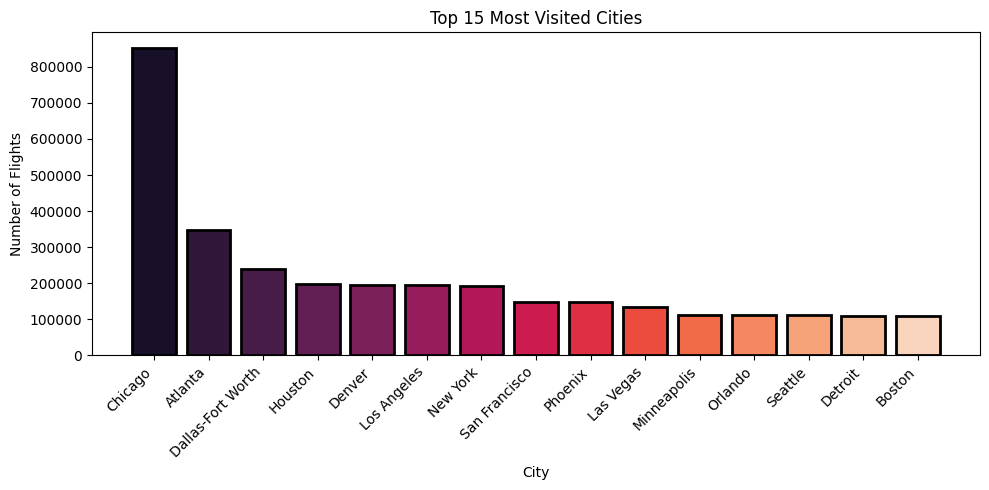

In [44]:
plt.figure(figsize=(10, 5))

city_counts = df['DESTINATION_CITY'].value_counts().head(15)
color = sns.color_palette("rocket", len(city_counts))

plt.bar(city_counts.index, city_counts.values, color=color, edgecolor='black', linewidth=2)
plt.title('Top 15 Most Visited Cities')
plt.xlabel('City')
plt.ylabel('Number of Flights')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

3.7 Flights distribution on Airports

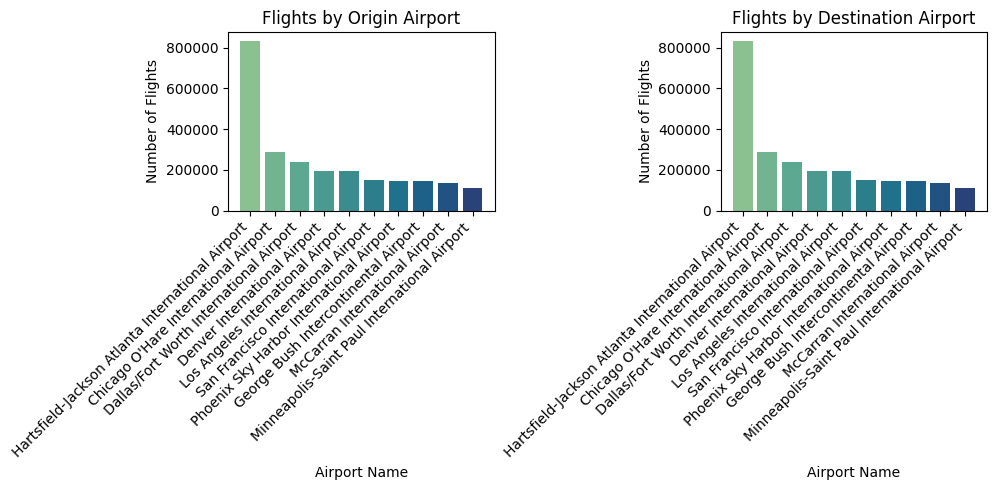

In [45]:
plt.figure(figsize=(10, 5))

airport_origin_counts = df['ORIGIN_AIRPORT_NAME'].value_counts().head(10)
airport_destination_counts = df['DESTINATION_AIRPORT_NAME'].value_counts().head(10)

color = sns.color_palette("crest", len(airport_origin_counts))

plt.subplot(1, 2, 1)
plt.bar(airport_origin_counts.index, airport_origin_counts.values, color=color)
plt.title('Flights by Origin Airport')
plt.xlabel('Airport Name')
plt.ylabel('Number of Flights')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 2, 2)
plt.bar(airport_destination_counts.index, airport_destination_counts.values, color=color)
plt.title('Flights by Destination Airport')
plt.xlabel('Airport Name')
plt.ylabel('Number of Flights')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

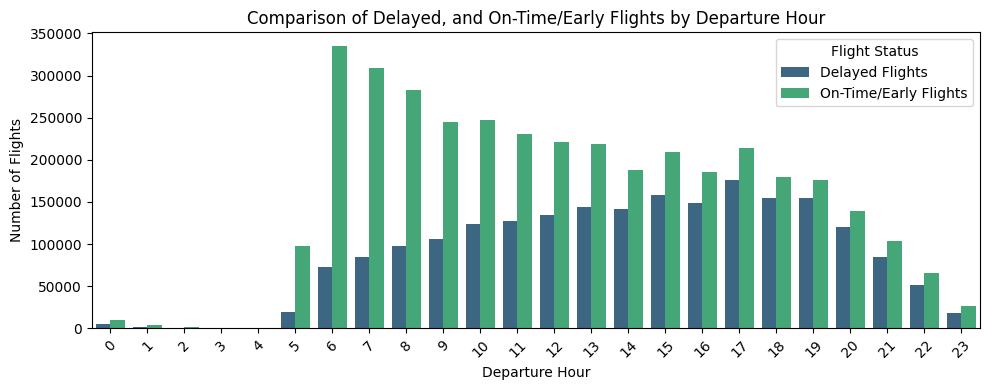

In [47]:
all_hours = pd.Series(range(24))

# Delayed flights (DEPARTURE_DELAY > 0) per hour
delayed_flights_by_hour = df[df['DEPARTURE_DELAY'] > 0].groupby('DEPARTURE_HOUR').size().reindex(all_hours, fill_value=0)

# On-time or early flights (DEPARTURE_DELAY <= 0) per hour
on_time_early_flights_by_hour = df[df['DEPARTURE_DELAY'] <= 0].groupby('DEPARTURE_HOUR').size().reindex(all_hours, fill_value=0)

plot_df = pd.DataFrame({
    'Delayed Flights': delayed_flights_by_hour,
    'On-Time/Early Flights': on_time_early_flights_by_hour
}).reset_index()
plot_df = plot_df.rename(columns={'index': 'Departure Hour'})
plot_df_melted = plot_df.melt(id_vars='Departure Hour', var_name='Flight Status', value_name='Number of Flights')

plt.figure(figsize=(10, 4))
sns.barplot(data=plot_df_melted, x='Departure Hour', y='Number of Flights', hue='Flight Status', palette='viridis')
plt.title('Comparison of Delayed, and On-Time/Early Flights by Departure Hour')
plt.xlabel('Departure Hour')
plt.ylabel('Number of Flights')
plt.xticks(rotation=45)
plt.legend(title='Flight Status')
plt.tight_layout()
plt.show()


## Week 4: Delay Analysis – Airline and Weather
1. Compare delay causes by airline 
2. Explore carrier delays, weather delays, NAS delays 
3. Visualize delays by time of day and airport

4.1 Compare delay causes by airline

In [54]:
for dtype in df.dtypes.unique():
    print(f"\n===== {dtype} =====")
    # print(df.select_dtypes(include=[dtype]).columns.tolist())



===== int16 =====

===== int8 =====

===== category =====

===== float32 =====

===== category =====

===== category =====

===== category =====

===== category =====

===== category =====

===== category =====

===== datetime64[ns] =====

===== int64 =====

===== category =====

===== bool =====


In [55]:
delay_cols = [
    'AIRLINE_DELAY', 'WEATHER_DELAY', 'SECURITY_DELAY',
    'LATE_AIRCRAFT_DELAY', 'AIR_SYSTEM_DELAY'
]

airline_delay_summary = df.groupby('AIRLINE_NAME')[delay_cols].mean().sort_values('AIRLINE_DELAY', ascending=False)
airline_delay_summary.head()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_28140\2984565105.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  airline_delay_summary = df.groupby('AIRLINE_NAME')[delay_cols].mean().sort_values('AIRLINE_DELAY', ascending=False)


,AIRLINE_DELAY,WEATHER_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,AIR_SYSTEM_DELAY
AIRLINE_NAME,,,,,
United Air Lines Inc.,4.293609,0.630269,0.002530,5.283402,2.928650
Atlantic Southeast Airlines,4.132986,0.296014,0.000000,4.596297,2.950982
JetBlue Airways,4.021959,0.433518,0.042753,5.308020,3.712670
Spirit Air Lines,4.013623,0.375604,0.043849,5.973965,8.020370
Frontier Airlines Inc.,3.819521,0.237967,0.000000,6.980041,6.398718


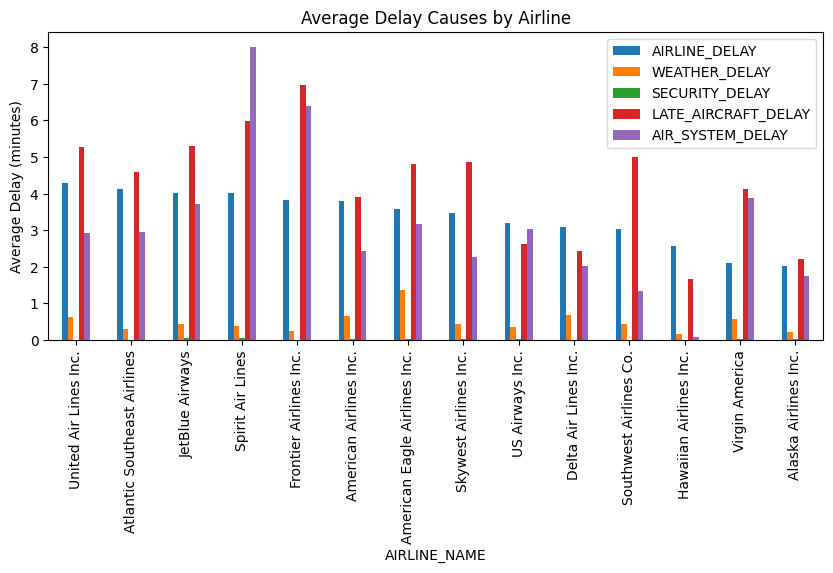

In [57]:
airline_delay_summary.plot(kind='bar', figsize=(10,4))
plt.title("Average Delay Causes by Airline")
plt.ylabel("Average Delay (minutes)")
plt.show()

4.2 Explore carrier delays, weather delays, NAS delays

In [58]:
cause_totals = df[delay_cols].sum().sort_values(ascending=False)
cause_totals

LATE_AIRCRAFT_DELAY    24961932.0
AIRLINE_DELAY          20172956.0
AIR_SYSTEM_DELAY       14335762.0
WEATHER_DELAY           3100233.0
SECURITY_DELAY            80985.0
dtype: float32

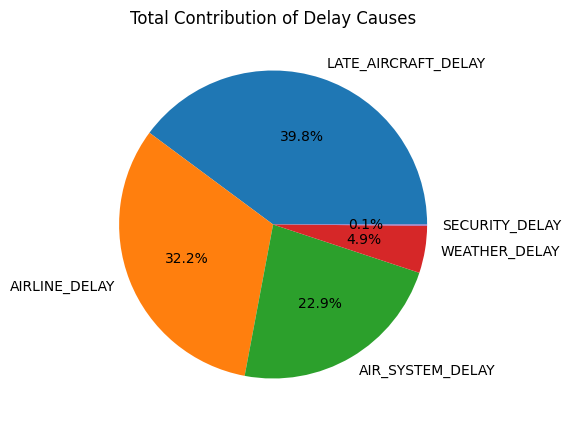

In [ ]:

cause_totals.plot(kind='pie', autopct='%1.1f%%', figsize=(5,5))
plt.title("Total Contribution of Delay Causes")
plt.ylabel("")  # hide y-label
plt.show()

4.3 Visualize delays by time of day and airport

In [ ]:
# Convert departure time to hour
df['DEP_HOUR'] = (df['SCHEDULED_DEPARTURE'] // 100).astype('int16')

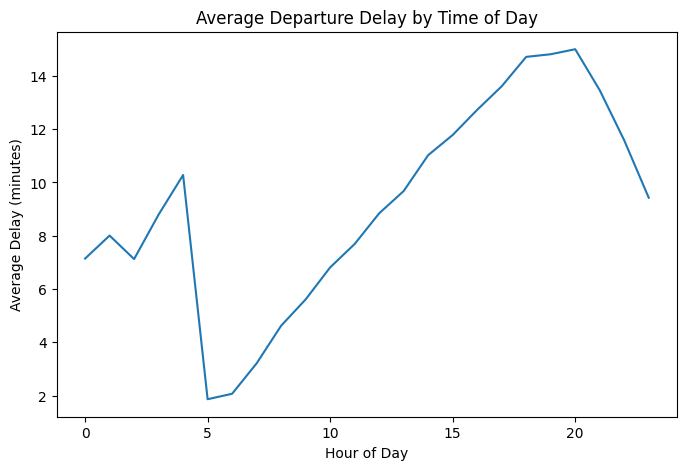

In [63]:
# Average delay by hour of day
hourly_delay = df.groupby('DEP_HOUR')['DEPARTURE_DELAY'].mean()
hourly_delay.plot(figsize=(8,5))
plt.title("Average Departure Delay by Time of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average Delay (minutes)")
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_28140\2907579061.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  airport_delay = df.groupby('ORIGIN_AIRPORT_NAME')['DEPARTURE_DELAY'].mean().sort_values(ascending=False).head(15)


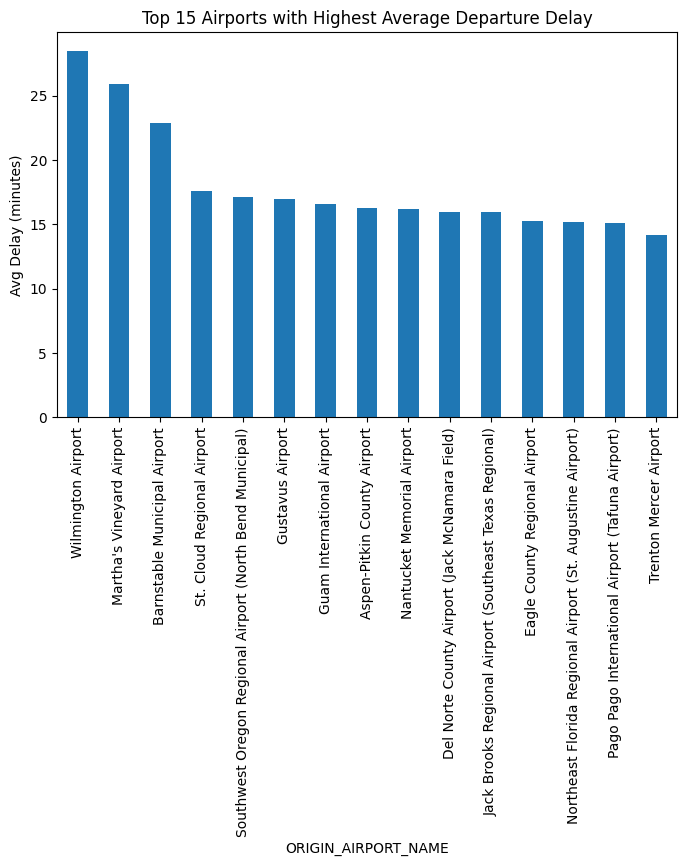

In [ ]:
#  Average delay by airport
airport_delay = df.groupby('ORIGIN_AIRPORT_NAME')['DEPARTURE_DELAY'].mean().sort_values(ascending=False).head(15)
airport_delay.plot(kind='bar', figsize=(8,5))
plt.title("Top 15 Airports with Highest Average Departure Delay")
plt.ylabel("Avg Delay (minutes)")
plt.show()